# Использование BERT для задачи классификации последовательности




[Исходный туториал](https://curiousily.com/posts/sentiment-analysis-with-bert-and-hugging-face-using-pytorch-and-python/) + материалы курса Кати Артемовой  на ФКН

**Важные ссылки про BERT**

[Devlin et al 2019](https://arxiv.org/pdf/1810.04805.pdf) - BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding - статья, презентующая BERT

[Vaswani et al 2017](https://papers.nips.cc/paper/2017/file/3f5ee243547dee91fbd053c1c4a845aa-Paper.pdf) - Attention is all you need - статья, презентующая трансформеры

[Illustrated Transformer](http://jalammar.github.io/illustrated-transformer/) by Jay Allamar - архитектура трансформера в картингах и гифках

[Annotated Transformer](https://nlp.seas.harvard.edu/2018/04/03/attention.html) by harvardnlp -код трансформера на торче, реализующий статью по абзацам

[Transformers](https://huggingface.co/transformers/) by hugging face -  главная open source библиотека, откуда можно брать предобученные бертоподобные модели


Сегодня посмотрим, как можно использовать BERT (или любую другую подобную модель) с помощью библиотеки Transformers.

Общий пайплайн:
BERT используется как начальный блок модели и считает контекстные вектора для слов.
Поверх этого блока мы добавляем "голову" модели, ее архитектура зависит от задачи.
Веса BERT предобучены, но мы проводим дообучение (fine-tuning) на целевой задаче.




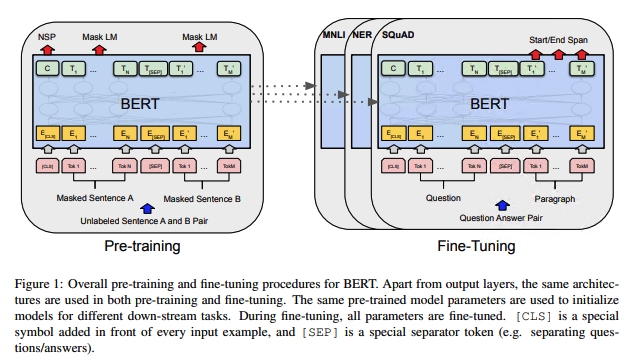

Наша сегодняшняя задача - классификация отзывов.
Данные - отзывы на приложения в Google Play, классы:  negative (1,2), neutral (3), positive (4,5)

# **Задание 1. 10 баллов (+2)**


Решите задачу классификации по тональности на подготовленном в одной из семинарских тетрадок корпусе отзывов Google Play, либо на корпусе IMDB, используя пайплайн с Trainer от HuggingFace.

1. обучите ту модель, которую мы разбирали на занятии (класс SentimentClassifier из тетрадки) -- 2 балла

2. измените модель, чтобы помимо выхода с пуллер-слоя использовался эмбеддинг cls-токена с последнего слоя. -- 3 балла

3. примените к данным готовую модель для классификации последовательности (типа BertForSequenceClassification) -- 2 балла


Для всех моделей используйте одинаковые гиперпараметры, чтобы их результаты можно было сравнить между собой.

Комментируйте ваши решения в коде.

Для каждой из моделей нужно привести результаты на тестовой выборке.

Вы можете использовать любую предобученную модель, которая подходит для работы с английским, кроме bert-base-cased

## Загрузка данных

Мы будем использовать библиотеку [Transformers](https://huggingface.co/transformers/) от Hugging Face

In [1]:
!pip install -q -U watermark # устанавливает пакет watermark, который используется для отображения информации о среде выполнения

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 24.8 MB/s eta 0:00:00


In [2]:
!pip install transformers # Устанавливает библиотеку transformers от Hugging Face, которая предоставляет инструменты для работы с предобученными моделями трансформеров (BERT, GPT)

In [3]:
%reload_ext watermark # перезагружает расширение watermark, чтобы обновить информацию о версиях библиотек после установки новых пакетов
%watermark -v -p numpy,pandas,torch,transformers # выводит информацию о версиях Python и перечисленных библиотек

Python implementation: CPython
Python version       : 3.11.11
IPython version      : 7.34.0

numpy       : 1.26.4
pandas      : 2.2.2
torch       : 2.5.1+cu121
transformers: 4.47.1



Загрузим набор данных, который мы будем использовать для обучения и тестирования модели -- отзывы на приложения в Google Play.


In [4]:
!gdown --id 1S6qMioqPJjyBLpLVz4gmRTnJHnjitnuV # получения данных или моделей
!gdown --id 1zdmewp7ayS4js4VtrJEHzAheSW-5NBZv

/usr/local/lib/python3.11/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1S6qMioqPJjyBLpLVz4gmRTnJHnjitnuV
To: /content/apps.csv
100% 134k/134k [00:00<00:00, 4.01MB/s]
/usr/local/lib/python3.11/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1zdmewp7ayS4js4VtrJEHzAheSW-5NBZv
To: /content/reviews.csv
100% 7.17M/7.17M [00:00<00:00, 36.4MB/s]


In [5]:
import transformers #библиотека transformers
from transformers import BertModel, AutoTokenizer, BertTokenizer, PreTrainedTokenizerFast, AdamW, get_linear_schedule_with_warmup
import torch.nn.functional as F
# AutoTokenizer - автоматически выбирает подходящий токенизатор для модели, BertTokenizer: токенизатор для модели BERT, PreTrainedTokenizerFast: быстрый токенизатор для предобученных моделей
# get_linear_schedule_with_warmup: функция для создания обучения с линейным затуханием
import torch
import numpy as np
import pandas as pd
import seaborn as sns
from pylab import rcParams
import matplotlib.pyplot as plt
from matplotlib import rc
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from collections import defaultdict
from textwrap import wrap
from torch import nn, optim
from torch.nn.utils import clip_grad_norm_ # используется для обрезки градиентов во время обучения модели, чтобы предотвратить проблемы с исчезающими или взрывающимися градиентами
from torch.utils.data import Dataset, DataLoader


In [6]:
%matplotlib inline
%config InlineBackend.figure_format='retina'
sns.set(style='whitegrid', palette='muted', font_scale=1.2)
HAPPY_COLORS_PALETTE = ["#01BEFE", "#FFDD00", "#FF7D00", "#FF006D", "#ADFF02", "#8F00FF"]
sns.set_palette(sns.color_palette(HAPPY_COLORS_PALETTE))
rcParams['figure.figsize'] = 8, 6

In [7]:
df = pd.read_csv("reviews.csv")

In [8]:
df.shape

(15746, 11)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15746 entries, 0 to 15745
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   userName              15746 non-null  object
 1   userImage             15746 non-null  object
 2   content               15746 non-null  object
 3   score                 15746 non-null  int64 
 4   thumbsUpCount         15746 non-null  int64 
 5   reviewCreatedVersion  13533 non-null  object
 6   at                    15746 non-null  object
 7   replyContent          7367 non-null   object
 8   repliedAt             7367 non-null   object
 9   sortOrder             15746 non-null  object
 10  appId                 15746 non-null  object
dtypes: int64(2), object(9)
memory usage: 1.3+ MB


In [10]:
from google.colab import data_table # модуль data_table из Google Colab
data_table.disable_dataframe_formatter() #Отключает автоматическое форматирование DataFrame в Google Colab, чтобы вывод данных отображался в стандартном текстовом формате, полезно для улучшения читаемости при выводе больших объемов данных

In [11]:
df.head()

,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,sortOrder,appId
0,Andrew Thomas,https://lh3.googleusercontent.com/a-/AOh14GiHd...,Update: After getting a response from the deve...,1,21,4.17.0.3,2020-04-05 22:25:57,"According to our TOS, and the term you have ag...",2020-04-05 15:10:24,most_relevant,com.anydo
1,Craig Haines,https://lh3.googleusercontent.com/-hoe0kwSJgPQ...,Used it for a fair amount of time without any ...,1,11,4.17.0.3,2020-04-04 13:40:01,It sounds like you logged in with a different ...,2020-04-05 15:11:35,most_relevant,com.anydo
2,steven adkins,https://lh3.googleusercontent.com/a-/AOh14GiXw...,Your app sucks now!!!!! Used to be good but no...,1,17,4.17.0.3,2020-04-01 16:18:13,This sounds odd! We are not aware of any issue...,2020-04-02 16:05:56,most_relevant,com.anydo
3,Lars Panzerbjørn,https://lh3.googleusercontent.com/a-/AOh14Gg-h...,"It seems OK, but very basic. Recurring tasks n...",1,192,4.17.0.2,2020-03-12 08:17:34,We do offer this option as part of the Advance...,2020-03-15 06:20:13,most_relevant,com.anydo
4,Scott Prewitt,https://lh3.googleusercontent.com/-K-X1-YsVd6U...,Absolutely worthless. This app runs a prohibit...,1,42,4.17.0.2,2020-03-14 17:41:01,We're sorry you feel this way! 90% of the app ...,2020-03-15 23:45:51,most_relevant,com.anydo


Посмотрим на распределение классов в выборке

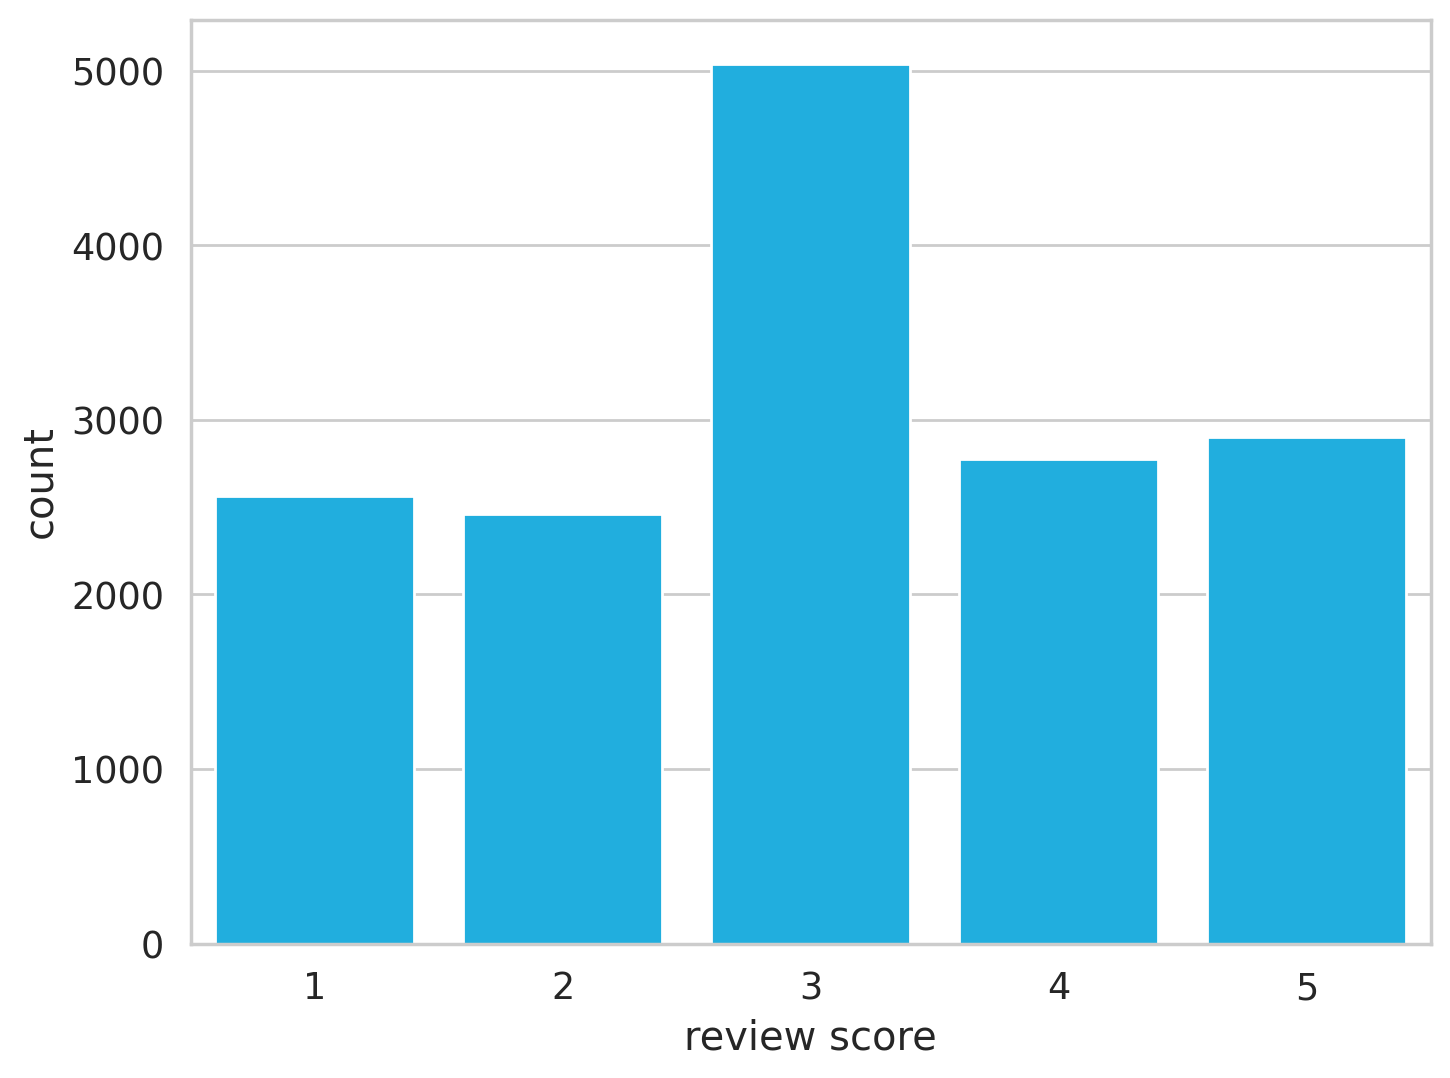

In [ ]:
sns.countplot(x=df.score)
plt.xlabel('review score');

Можно видеть, что данные несбалансированы.
Теперь приведем метки классов к другому виду -- разделим их на 3 класса: негативные, нейтральные и позитивные.

In [12]:
def to_sentiment(rating):
  rating = int(rating)
  if rating <= 2:
    return 0
  elif rating == 3:
    return 1
  else:
    return 2

df['sentiment'] = df.score.apply(to_sentiment)

In [13]:
class_names = ['negative', 'neutral', 'positive']

<ipython-input-15-c8622670199a>:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(class_names);


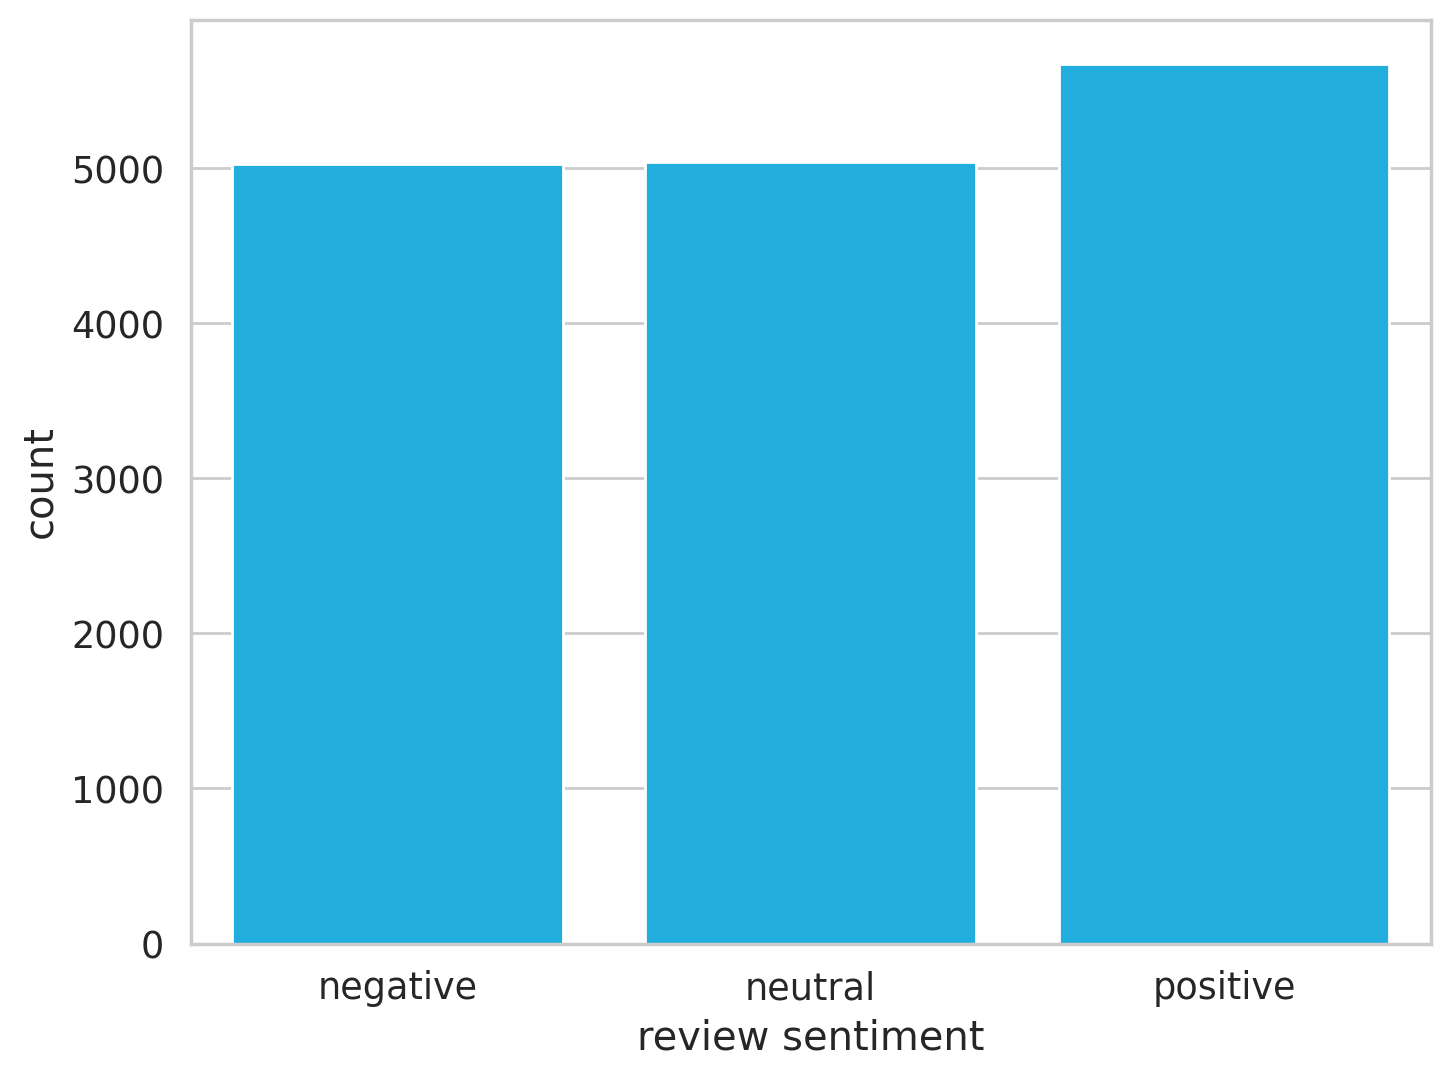

In [ ]:
ax = sns.countplot(x=df.sentiment)
plt.xlabel('review sentiment')
ax.set_xticklabels(class_names);

В таком виде классы почти сбалансированы.

## Предобработка данных

Для обучение модели BERT нам нужно обработать исходный текст определенным образом:
* Добавить служебные символы для разделения предложений и классификации
* Привести все последовательности к единой длине (используя padding)
* Создать список (*attention mask*) из 0 и 1, в котором 0 будут соответствовать вспомогательным токенам (padding), а 1 $-$ настоящим.



Бертоподобных моделей огромное множество, но если они интегрированы в библиотеку Transformers, сменить одну модель на другую очень просто. Вот [здесь](https://huggingface.co/transformers/pretrained_models.html) можно посмотреть, какие модели есть библиотеке.

Model id в таблице используются для двух вещей - подгрузки весов в саму модель и подгрузки правильного токенизатора. Вам не нужно самим добавлять спецсимволы и строить индексы словаря, это сделает токенайзер, соотвествующий выбранной модели.
Сегодняшний выбор - модель 'bert-base-cased'

In [ ]:
#from transformers import AutoTokenizer, AutoModelForMaskedLM
# Взяла отсюда: https://huggingface.co/google-bert/bert-base-uncased?library=transformers

In [14]:
PRE_TRAINED_MODEL_NAME = 'google-bert/bert-base-uncased' #нельзя брать bert-base-cased, взяла uncased, они немного отличаются

Загрузим предобученный [BertTokenizer](https://huggingface.co/transformers/model_doc/bert.html#berttokenizer):

In [15]:
tokenizer = BertTokenizer.from_pretrained(PRE_TRAINED_MODEL_NAME) #предобученный токенизатор BERT с использованием имени модели, будет использоваться для преобразования текста в токены

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

In [ ]:
#tokenizer = AutoTokenizer.from_pretrained("google-bert/bert-large-cased-whole-word-masking")

Посмотрим, как работает модель токенизации для BERT.



In [16]:
sample_txt = 'When was I last outside? I am stuck at home for 2 weeks.'
tokens = tokenizer.tokenize(sample_txt) #применяет токенизатор к тексту
token_ids = tokenizer.convert_tokens_to_ids(tokens) # Преобразует полученные токены в  числовые представления

print(f' Sentence: {sample_txt}')
print(f'   Tokens: {tokens}')
print(f'Token IDs: {token_ids}')

 Sentence: When was I last outside? I am stuck at home for 2 weeks.
   Tokens: ['when', 'was', 'i', 'last', 'outside', '?', 'i', 'am', 'stuck', 'at', 'home', 'for', '2', 'weeks', '.']
Token IDs: [2043, 2001, 1045, 2197, 2648, 1029, 1045, 2572, 5881, 2012, 2188, 2005, 1016, 3134, 1012]


In [17]:
sample_txt = 'He started a new book, it was quite readable'

tokens = tokenizer.tokenize(sample_txt)
token_ids = tokenizer.convert_tokens_to_ids(tokens)

print(f' Sentence: {sample_txt}')
print(f'   Tokens: {tokens}')
print(f'Token IDs: {token_ids}')

 Sentence: He started a new book, it was quite readable
   Tokens: ['he', 'started', 'a', 'new', 'book', ',', 'it', 'was', 'quite', 'read', '##able']
Token IDs: [2002, 2318, 1037, 2047, 2338, 1010, 2009, 2001, 3243, 3191, 3085]


##  Специальные токены

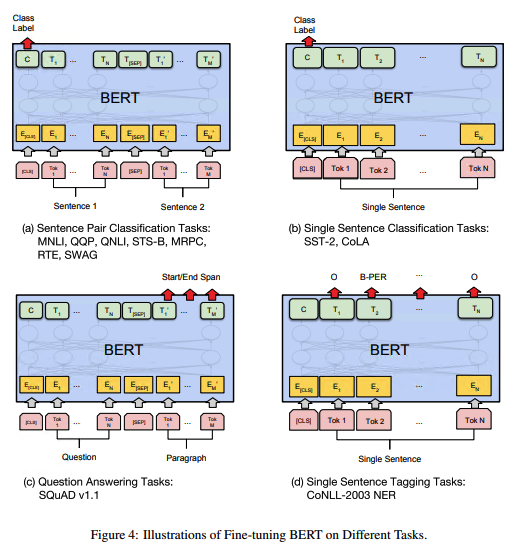



`[SEP]` - метка конца предложения


In [18]:
tokenizer.sep_token, tokenizer.sep_token_id #символ и идентификатор специального токена [SEP], который используется для разделения предложений в BERT

('[SEP]', 102)

`[CLS]` - чтобы использовать модель BERT для классификации, мы должны добавить этот токен в начало каждого предложения

In [19]:
tokenizer.cls_token, tokenizer.cls_token_id #получает символ и идентификатор специального токена [CLS], который используется в начале входной последовательности для задач классификации

('[CLS]', 101)

Также существует специальный вспомогательный токен для выравнивания длин последовательностей

In [20]:
tokenizer.pad_token, tokenizer.pad_token_id #получает символ и идентификатор специального токена [PAD], который используется для дополнения последовательностей до одинаковой длины

('[PAD]', 0)

Вся эта предобработка может быть сделана с помощью метода encode_plus

In [21]:
encoding = tokenizer.encode_plus( #метод encode_plus для преобразования текста в формат, подходящий для подачи в модель BERT
  sample_txt,
  max_length=32, #максимальная длина выходной последовательности
  add_special_tokens=True, # добавляет специальные токены [CLS] и [SEP].
  return_token_type_ids=False, #используется для задач с несколькими предложениями
  padding='max_length', #последовательность до максимальной длины
  return_attention_mask=True, #возвращает маску внимания, которая указывает модели, какие токены следует учитывать
  return_tensors='pt',  # Вернуть тензор PyTorch
  truncation=True #обрезает последовательность, если она превышает максимальную длину
)

encoding.keys() # ключи словаря encoding, чтобы увидеть, какие данные были возвращены после кодирования текста

dict_keys(['input_ids', 'attention_mask'])

In [22]:
print(len(encoding['input_ids'][0])) # длину первой (и единственной) последовательности идентификаторов входных токенов
encoding['input_ids'][0] #показывает первую (и единственную) последовательность идентификаторов входных токенов

32


tensor([ 101, 2002, 2318, 1037, 2047, 2338, 1010, 2009, 2001, 3243, 3191, 3085,
         102,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0])

Такая же длина будет и у *attention mask*

In [23]:
print(len(encoding['attention_mask'][0])) #длину первой (и единственной) маски внимания. Это также должно быть равно max_length.
encoding['attention_mask'] #показывает маску внимания из словаря encoding

32


tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0]])

In [24]:
tokenizer.convert_ids_to_tokens(encoding['input_ids'][0]) #преобразует идентификаторы входных токенов обратно в соответствующие токены с помощью метода convert_ids_to_tokens


['[CLS]',
 'he',
 'started',
 'a',
 'new',
 'book',
 ',',
 'it',
 'was',
 'quite',
 'read',
 '##able',
 '[SEP]',
 '[PAD]',
 '[PAD]',
 '[PAD]',
 '[PAD]',
 '[PAD]',
 '[PAD]',
 '[PAD]',
 '[PAD]',
 '[PAD]',
 '[PAD]',
 '[PAD]',
 '[PAD]',
 '[PAD]',
 '[PAD]',
 '[PAD]',
 '[PAD]',
 '[PAD]',
 '[PAD]',
 '[PAD]']

Установим максимальную длину последовательности равной 160

In [25]:
MAX_LEN = 160 #все входные тексты будут обрезаны или дополнены до этой длины

Теперь создадим датасет PyTorch, который понадобится в дальнейшем для обучения модели

In [26]:

class GPReviewDataset(Dataset):

  def __init__(self, reviews, targets, tokenizer, max_len):
    self.reviews = reviews
    self.targets = targets
    self.tokenizer = tokenizer
    self.max_len = max_len

  def __len__(self):
    return len(self.reviews)

  def __getitem__(self, item):
    review = str(self.reviews[item])
    target = self.targets[item]

    encoding = self.tokenizer.encode_plus(
      review,
      add_special_tokens=True,
      max_length=self.max_len,
      return_token_type_ids=False,
      padding='max_length',
      return_attention_mask=True,
      return_tensors='pt',
      truncation=True # токенизатор обрезать последовательность
    )

    return {
      'review_text': review,
      'input_ids': encoding['input_ids'].flatten(), #идентификаторы входных токенов в словаре под ключом 'input_ids'. flatten() используется для преобразования тензора в одномерный массив
      'attention_mask': encoding['attention_mask'].flatten(), # маску внимания в словаре под ключом attention_mask
      'targets': torch.tensor(target, dtype=torch.long) # преобразует целевую метку в тензор PyTorch и сохраняет его в словаре под ключом targets
    }

Разделим данные на обучающую, тестовую и валидационную выборки

In [27]:
RANDOM_SEED = 42 # устанавливаю seed
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [28]:
device

device(type='cuda', index=0)

In [29]:
df_train, df_test = train_test_split(df, test_size=0.1, random_state=RANDOM_SEED)
df_val, df_test = train_test_split(df_test, test_size=0.5, random_state=RANDOM_SEED)

In [30]:
df_train.shape, df_val.shape, df_test.shape # размеры (количество строк и столбцов) обучающего, валидационного и тестового наборов данных

((14171, 12), (787, 12), (788, 12))


Создадим итераторы по данным
- train_data_loader - данные для обучения
- val_data_loader - данные для валидации модели при обучении
- test_data_loader - данные для тестирования модели

In [31]:
import warnings
warnings.filterwarnings('ignore')

In [32]:
def create_data_loader(df, tokenizer, max_len, batch_size):
  ds = GPReviewDataset(
    reviews=df.content.to_numpy(),
    targets=df.sentiment.to_numpy(),
    tokenizer=tokenizer,
    max_len=max_len
  )

  return DataLoader(
    ds,
    batch_size=batch_size,
    num_workers=1
  )
# значение num_workers=1 в PyTorch означает, что для загрузки данных используется только один рабочий процесс, но при этом процесс будет относительно медленным

In [33]:
BATCH_SIZE = 16

train_data_loader = create_data_loader(df_train, tokenizer, MAX_LEN, BATCH_SIZE)
val_data_loader = create_data_loader(df_val, tokenizer, MAX_LEN, BATCH_SIZE)
test_data_loader = create_data_loader(df_test, tokenizer, MAX_LEN, BATCH_SIZE)

Посмотрим на пример одного батча из нашего итератора train_data_loader



In [34]:
data = next(iter(train_data_loader))

In [35]:
data.keys()

dict_keys(['review_text', 'input_ids', 'attention_mask', 'targets'])

In [36]:
print(data['review_text'])
print(data['input_ids'].shape)
print(data['attention_mask'].shape)
print(data['targets'].shape)

["You can't have your to do list as notifications", "I haven't been using this very long and it's not as user friendly as the Calender that came on my last phone.  I wish instead of dots you can just see what you have entered for that day immediately without tapping on that day.  Otherwise it is easy to use and functional.", '1. Кривой и неработающий экспорт и импорт. 2. Нельзя удалить базовые навыки, заданий и характеристики. 3. Нельзя удалять сразу несколько навыков, заданий и характеристик. 4. Кнопка отчислить данные не удаляет всё, а только откатывает к базовым. Спустя пару месяцев снова установил приложение. Загрузил с автосохронерия данных - загрузилось всё базовое и с диска тоже самое (настройки тоже). Проверял после установки изменяя данные и сохраняя их потом. Итог: после загрузки зброс к базовым.', 'Love it so far. Wish it had a widget for Android though.', "Liked the prioritization by dragging and the highlighting, but there does not seem to be a way to create recurring task

In [37]:
data['targets']

tensor([0, 1, 1, 1, 0, 2, 1, 1, 2, 2, 0, 0, 0, 0, 2, 0])

## Классификация сентимента с использованием модели BERT от Hugging Face


В библиотеке Transformers от Hugging Face есть много моделей для разных задач: [BertForSequenceClassification](https://huggingface.co/transformers/model_doc/bert.html#bertforsequenceclassification), [BertForQuestionAnswering](https://huggingface.co/transformers/model_doc/bert.html#bertforquestionanswering) и другие. Все они являются надстройками над базовой моделью BERT.

В данном случае мы будем использовать базовую модель [BertModel](https://huggingface.co/transformers/model_doc/bert.html#bertmodel) и реализуем на её основе свой классификатор текстов по тональности.

In [38]:
bert_model = BertModel.from_pretrained(PRE_TRAINED_MODEL_NAME) # загружает предобученную модель BERT с указанным именем модели. Это позволяет использовать уже обученные веса модели для дальнейшего обучения

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

In [39]:
bert_model

BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSdpaSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False

Попробуем использовать эту модель

In [40]:
tokenizer.convert_ids_to_tokens(encoding['input_ids'][0]) # преобразует идентификаторы токенов из первого примера в соответствующие текстовые токены

['[CLS]',
 'he',
 'started',
 'a',
 'new',
 'book',
 ',',
 'it',
 'was',
 'quite',
 'read',
 '##able',
 '[SEP]',
 '[PAD]',
 '[PAD]',
 '[PAD]',
 '[PAD]',
 '[PAD]',
 '[PAD]',
 '[PAD]',
 '[PAD]',
 '[PAD]',
 '[PAD]',
 '[PAD]',
 '[PAD]',
 '[PAD]',
 '[PAD]',
 '[PAD]',
 '[PAD]',
 '[PAD]',
 '[PAD]',
 '[PAD]']

In [41]:
encoding['attention_mask']
# извлекает маску внимания из переменной encoding
# маска указывает, какие токены следует учитывать при обработке (1 для токенов, которые следует учитывать, и 0 для паддингов)

tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0]])

In [42]:
last_hidden_state, pooled_output, hidden_states = bert_model(
  input_ids=encoding['input_ids'],
  attention_mask=encoding['attention_mask'],
  output_hidden_states=True,
  return_dict=False)
# пропускает входные идентификаторы и маску внимания через модель BERT
#  last_hidden_state: последний скрытый слой модели (тензор с представлениями токенов)
#  pooled_output: агрегированное представление (обычно для [CLS] токена)
#  hidden_states: скрытые состояния всех слоев (если output_hidden_states=True)
# return_dict=False: указывает возвращать результаты не в виде словаря, а как кортеж


В переменную last_hidden_state теперь записана последовательность скрытых состояний последнего слоя модели.

In [43]:
print(last_hidden_state.shape)
print(pooled_output.shape)
print(len(hidden_states))

torch.Size([1, 32, 768])
torch.Size([1, 768])
13


In [44]:
for state in hidden_states:
  print(state.shape)

torch.Size([1, 32, 768])
torch.Size([1, 32, 768])
torch.Size([1, 32, 768])
torch.Size([1, 32, 768])
torch.Size([1, 32, 768])
torch.Size([1, 32, 768])
torch.Size([1, 32, 768])
torch.Size([1, 32, 768])
torch.Size([1, 32, 768])
torch.Size([1, 32, 768])
torch.Size([1, 32, 768])
torch.Size([1, 32, 768])
torch.Size([1, 32, 768])


Посмотрим на BERT эмбеддинги некоторых слов в предложениях.

In [45]:
text1 = df.loc[16]['content']
text2 = df.loc[338]['content']
print(text1)
print(text2)

Couldn't even set up one single recurring reminder without being required to pay monthly subscription. Get your greedy hand off it dev. It's only only a reminder app not a useful service.
Well designed and all however alot of the crutial features are locked behind the premium which u need to pay for


In [46]:
tokenizer = BertTokenizer.from_pretrained(PRE_TRAINED_MODEL_NAME) # загружает токенизатор BERT из предобученной модели
tokenizer2 = PreTrainedTokenizerFast.from_pretrained(PRE_TRAINED_MODEL_NAME) # загружает более быстрый токенизатор (обычно использующийся для обработки текстов) из той же предобученной модели

The tokenizer class you load from this checkpoint is not the same type as the class this function is called from. It may result in unexpected tokenization. 
The tokenizer class you load from this checkpoint is 'BertTokenizer'. 
The class this function is called from is 'PreTrainedTokenizerFast'.


In [47]:
tokenizer2.sep_token = tokenizer.sep_token
tokenizer2.pad_token = tokenizer.pad_token
# специальные токены (разделитель и паддинг)

In [48]:
encoding = tokenizer.encode_plus(
  text1,
  max_length=30,
  add_special_tokens=True, # Добавить '[CLS]' и '[SEP]'
  return_token_type_ids=False,
  padding='max_length',
  return_attention_mask=True,
  return_tensors='pt',  # Вернуть тензор PyTorch
  truncation=True
)

In [49]:
encoding2 = tokenizer2.encode_plus(
  text1,
  max_length=50,
  add_special_tokens=True, # добавляет специальные токены [CLS] в начале и [SEP] в конце
  return_token_type_ids=False,
  padding='max_length', #добавляет паддинг до максимальной длины 30
  return_attention_mask=True,
  return_tensors='pt',  # Вернуть тензор PyTorch
  truncation=True,
  return_offsets_mapping=True # возвращает информацию о начальных и конечных позициях каждого токена в исходном тексте
)

In [50]:
print(encoding.keys())
print(encoding2.keys())

dict_keys(['input_ids', 'attention_mask'])
dict_keys(['input_ids', 'attention_mask', 'offset_mapping'])


In [51]:
encoding2['offset_mapping']

tensor([[[  0,   0],
         [  0,   6],
         [  6,   7],
         [  7,   8],
         [  9,  13],
         [ 14,  17],
         [ 18,  20],
         [ 21,  24],
         [ 25,  31],
         [ 32,  41],
         [ 42,  50],
         [ 51,  58],
         [ 59,  64],
         [ 65,  73],
         [ 74,  76],
         [ 77,  80],
         [ 81,  88],
         [ 89, 101],
         [101, 102],
         [103, 106],
         [107, 111],
         [112, 118],
         [119, 123],
         [124, 127],
         [128, 130],
         [131, 134],
         [134, 135],
         [136, 138],
         [138, 139],
         [139, 140],
         [141, 145],
         [146, 150],
         [151, 152],
         [153, 161],
         [162, 165],
         [166, 169],
         [170, 171],
         [172, 178],
         [179, 186],
         [186, 187],
         [  0,   0],
         [  0,   0],
         [  0,   0],
         [  0,   0],
         [  0,   0],
         [  0,   0],
         [  0,   0],
         [  0

In [52]:
encoding['input_ids']

tensor([[  101,  2481,  1005,  1056,  2130,  2275,  2039,  2028,  2309, 10694,
         14764,  2302,  2108,  3223,  2000,  3477,  7058, 15002,  1012,  2131,
          2115, 20505,  2192,  2125,  2009, 16475,  1012,  2009,  1005,   102]])

In [53]:
last_hidden_state, pooled_output = bert_model(
  input_ids=encoding['input_ids'],
  attention_mask=encoding['attention_mask'],
  return_dict=False)
# last_hidden_state: последний скрытый слой модели (тензор, представляющий все токены)
#  pooled_output: агрегированное представление (обычно для токена [CLS])


In [54]:
print(tokenizer.convert_ids_to_tokens(encoding['input_ids'][0]))

['[CLS]', 'couldn', "'", 't', 'even', 'set', 'up', 'one', 'single', 'recurring', 'reminder', 'without', 'being', 'required', 'to', 'pay', 'monthly', 'subscription', '.', 'get', 'your', 'greedy', 'hand', 'off', 'it', 'dev', '.', 'it', "'", '[SEP]']


In [55]:
tokenizer.convert_ids_to_tokens(encoding['input_ids'][0]).index('subscription')

17

In [56]:
emb1 = last_hidden_state[0, 17]
emb1.shape

torch.Size([768])

In [57]:
encoding2 = tokenizer.encode_plus(
  text2,
  max_length=30,
  add_special_tokens=True, # Добавить '[CLS]' и '[SEP]'
  return_token_type_ids=False,
  padding='max_length',
  return_attention_mask=True,
  return_tensors='pt',  # Вернуть тензор PyTorch
  truncation=True
)

last_hidden_state2, pooled_output2 = bert_model(
  input_ids=encoding2['input_ids'],
  attention_mask=encoding2['attention_mask'],
  return_dict=False)

In [58]:
tokenizer.convert_ids_to_tokens(encoding2['input_ids'][0])

['[CLS]',
 'well',
 'designed',
 'and',
 'all',
 'however',
 'al',
 '##ot',
 'of',
 'the',
 'cr',
 '##uti',
 '##al',
 'features',
 'are',
 'locked',
 'behind',
 'the',
 'premium',
 'which',
 'u',
 'need',
 'to',
 'pay',
 'for',
 '[SEP]',
 '[PAD]',
 '[PAD]',
 '[PAD]',
 '[PAD]']

In [59]:
tokenizer.convert_ids_to_tokens(encoding2['input_ids'][0]).index('premium')

18

In [60]:
emb2 = last_hidden_state2[0, 1]
emb2.shape

torch.Size([768])

In [61]:
from sklearn.metrics.pairwise import cosine_similarity #вычисления косинусного сходства

In [62]:
cosine_similarity( [emb1.detach().cpu().numpy()], [emb2.detach().cpu().numpy()])
# detach() отключает тензоры от графа вычислений PyTorch, чтобы избежать ненужного отслеживания градиентов
# Косинусное сходство измеряет степень схожести между двумя векторами: значения варьируются от -1 (полностью противоположные) до 1 (полностью идентичные)

array([[0.24876867]], dtype=float32)

Опишем наконец наш классификатор на основе BertModel

In [63]:
class SentimentClassifier(nn.Module):

  def __init__(self, n_classes):
    # вызывается при создании нового экземпляра класса (model = SentimentClassifier(num_classes))
    # Он принимает self - ссылку на сам экземпляр и n_classes - количество выходных классов для классификатора значений  в качестве входных данных
    super().__init__()
    self.bert = BertModel.from_pretrained(PRE_TRAINED_MODEL_NAME) # создается экземпляр класса BertModel из библиотеки Hugging Face Transformers, загружается из предварительно подготовленных весов, хранящихся в каталоге PRE_TRAINED_MODEL_NAME
    self.drop = nn.Dropout(p=0.3)
    self.out = nn.Linear(self.bert.config.hidden_size, n_classes) # выходной слой классификатора, он принимает выходные данные модели BERT, которые представляют собой вектор размера self.bert.config.hidden_size, и преобразует его в вектор размера n_classes (количество классов настроений)

  def forward(self, input_ids, attention_mask):
    _, pooled_output = self.bert( # представление всей входной последовательности, обычно оно берется из встраивания токена [CLS]
      input_ids=input_ids,
      attention_mask=attention_mask,
      return_dict=False)
    output = self.drop(pooled_output)
    return self.out(output)

In [64]:
model = SentimentClassifier(len(class_names))
model = model.to(device)

In [65]:
model

SentimentClassifier(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, eleme

Перенесем на GPU один из наших батчей (для примера).

In [66]:
input_ids = data['input_ids'].to(device)
attention_mask = data['attention_mask'].to(device)

print(input_ids.shape) # batch size x seq length
print(attention_mask.shape) # batch size x seq length

torch.Size([16, 160])
torch.Size([16, 160])


Применим модель к данным.

In [67]:
output = model(input_ids, attention_mask)
output

tensor([[ 0.4403, -0.5204, -0.6500],
        [ 0.1137, -0.4435, -0.4563],
        [-0.1626,  0.1534, -0.1173],
        [ 0.2407, -0.3659, -0.1775],
        [ 0.0333, -0.2689, -0.2917],
        [ 0.2219,  0.0510, -0.2371],
        [-0.2436, -0.4242, -0.3342],
        [ 0.4689, -0.4074, -0.5399],
        [ 0.1587, -0.1000,  0.0240],
        [ 0.3366, -0.1122, -0.2344],
        [ 0.2503, -0.2995, -0.4393],
        [ 0.1848,  0.0218, -0.1260],
        [ 0.1181, -0.6058, -0.6131],
        [-0.3773, -0.1019, -0.3994],
        [ 0.1712,  0.1388, -0.3302],
        [ 0.1763, -0.2801, -0.5435]], device='cuda:0',
       grad_fn=<AddmmBackward0>)

Если хотим получить вероятности классов, применяем SoftMax к выходу модели.

In [68]:
F.softmax(output, dim=1)

tensor([[0.5818, 0.2226, 0.1956],
        [0.4676, 0.2679, 0.2645],
        [0.2926, 0.4013, 0.3061],
        [0.4538, 0.2474, 0.2987],
        [0.4062, 0.3003, 0.2935],
        [0.4041, 0.3406, 0.2553],
        [0.3639, 0.3037, 0.3324],
        [0.5615, 0.2338, 0.2047],
        [0.3779, 0.2918, 0.3303],
        [0.4539, 0.2897, 0.2564],
        [0.4810, 0.2776, 0.2414],
        [0.3872, 0.3290, 0.2838],
        [0.5086, 0.2466, 0.2448],
        [0.3035, 0.3997, 0.2968],
        [0.3885, 0.3761, 0.2353],
        [0.4716, 0.2988, 0.2296]], device='cuda:0', grad_fn=<SoftmaxBackward0>)

## Обучение модели

Для дообучения модели будем использовать оптимизатор [AdamW](https://huggingface.co/transformers/main_classes/optimizer_schedules.html#adamw) из библиотеки Hugging Face.



Авторы модели BERT рекомендуют использовать следующие параметры для дообучения модели:
- Размер батча: 16, 32
- Learning rate (с оптимайзером Adam): 5e-5, 3e-5, 2e-5
- Количество эпох: 2, 3, 4

In [69]:
#как заморозить отдельные слои
freeze_layers = list(range(5))
for layer_id in freeze_layers:
  for param in list(model.bert.encoder.layer[layer_id].parameters()):
    param.requires_grad = False


In [70]:
list(model.bert.encoder.layer[3].parameters())[0]

Parameter containing:
tensor([[ 0.0586, -0.0279,  0.0022,  ..., -0.0205,  0.0419,  0.0560],
        [-0.0011,  0.1283, -0.0564,  ..., -0.0514, -0.0199,  0.0516],
        [-0.0083,  0.0060, -0.0469,  ...,  0.0569, -0.0073, -0.0616],
        ...,
        [ 0.0118,  0.0645, -0.0159,  ..., -0.0027, -0.0031, -0.0141],
        [ 0.0029,  0.0531,  0.0221,  ..., -0.0047,  0.0399,  0.0344],
        [ 0.0512,  0.0246,  0.0077,  ...,  0.0108,  0.0262,  0.0081]],
       device='cuda:0')

In [71]:
EPOCHS = 2

#optimizer = AdamW(model.parameters(), lr=2e-5, correct_bias=False)
optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=2e-5, correct_bias=False)
total_steps = len(train_data_loader) * EPOCHS #вычисляет общее количество шагов обучения, количество шагов за период, умноженное на количество эпох

scheduler = get_linear_schedule_with_warmup(
  optimizer,
  num_warmup_steps=0, # скорость обучения в начале тренировки медленно увеличивается для лучшей конвергенции = 0
  num_training_steps=total_steps
)

loss_fn = nn.CrossEntropyLoss().to(device)

Реализуем функцию для одной эпохи обучения

Также реализуем функцию для оценки качества модели на данных из data_loader

Используя эти две функции, описанные выше, реализуем процедуру дообучения нашей модели

In [72]:
from tqdm import tqdm
# не люблю, когда не могу отслеживать прогресс, поэтому добавлю tqdm
def train_epoch(
  model,
  data_loader,
  loss_fn,
  optimizer,
  device,
  scheduler,
  n_examples
):
  model = model.train()

  losses = []
  correct_predictions = 0

  # Оборачиваю data_loader в tqdm для отображения прогресса
  for d in tqdm(data_loader, desc="Training"):
    input_ids = d["input_ids"].to(device)
    attention_mask = d["attention_mask"].to(device)
    targets = d["targets"].to(device)

    outputs = model(
      input_ids=input_ids,
      attention_mask=attention_mask
    )

    preds = torch.argmax(outputs, dim=1)
    loss = loss_fn(outputs, targets)

    correct_predictions += torch.sum(preds == targets)
    losses.append(loss.item())

    loss.backward()
    optimizer.step()
    scheduler.step()
    optimizer.zero_grad()

  return correct_predictions / n_examples, np.mean(losses)

def eval_model(model, data_loader, loss_fn, device, n_examples):
  model = model.eval()

  losses = []
  correct_predictions = 0

  with torch.no_grad():
    # Оборачиваю data_loader в tqdm для отображения прогресса
    for d in tqdm(data_loader, desc="Evaluating"):
      input_ids = d["input_ids"].to(device)
      attention_mask = d["attention_mask"].to(device)
      targets = d["targets"].to(device)

      outputs = model(
        input_ids=input_ids,
        attention_mask=attention_mask
      )
      preds = torch.argmax(outputs, dim=1)

      loss = loss_fn(outputs, targets)

      correct_predictions += torch.sum(preds == targets)
      losses.append(loss.item())

  return correct_predictions / n_examples, np.mean(losses)

history = defaultdict(list)
best_accuracy = 0

for epoch in range(EPOCHS):
  print(f'Epoch {epoch + 1}/{EPOCHS}')
  print('-' * 10)

  train_acc, train_loss = train_epoch(
    model,
    train_data_loader,
    loss_fn,
    optimizer,
    device,
    scheduler,
    len(df_train)
  )

  print(f'Train loss {train_loss} accuracy {train_acc}')

  val_acc, val_loss = eval_model(
    model,
    val_data_loader,
    loss_fn,
    device,
    len(df_val)
  )

  print(f'Val loss {val_loss} accuracy {val_acc}')
  print()

  history['train_acc'].append(train_acc)
  history['train_loss'].append(train_loss)
  history['val_acc'].append(val_acc)
  history['val_loss'].append(val_loss)

  if val_acc > best_accuracy:
    torch.save(model.state_dict(), 'best_model_state.bin')
    best_accuracy = val_acc

Epoch 1/2
----------


Training: 100%|██████████| 886/886 [05:12<00:00,  2.84it/s]


Train loss 0.712084994022787 accuracy 0.6746878027915955


Evaluating: 100%|██████████| 50/50 [00:06<00:00,  7.50it/s]


Val loss 0.5937318152189255 accuracy 0.7318932414054871

Epoch 2/2
----------


Training: 100%|██████████| 886/886 [05:15<00:00,  2.81it/s]


Train loss 0.4961818695808372 accuracy 0.7940160036087036


Evaluating: 100%|██████████| 50/50 [00:06<00:00,  7.53it/s]


Val loss 0.5557140693068504 accuracy 0.7763659358024597



In [ ]:
torch.cuda.empty_cache()


При обучении модели мы сохраняем веса наилучшей модели на основе точности на валидационной выборке.

Обучение модели занимает некоторое время. Теперь мы можем сравнить точность на валидационной и на обучающей выборке.

In [73]:
history['train_acc'] = [score.to('cpu') for score in  history['train_acc']]
history['val_acc'] = [score.to('cpu') for score in  history['val_acc']]

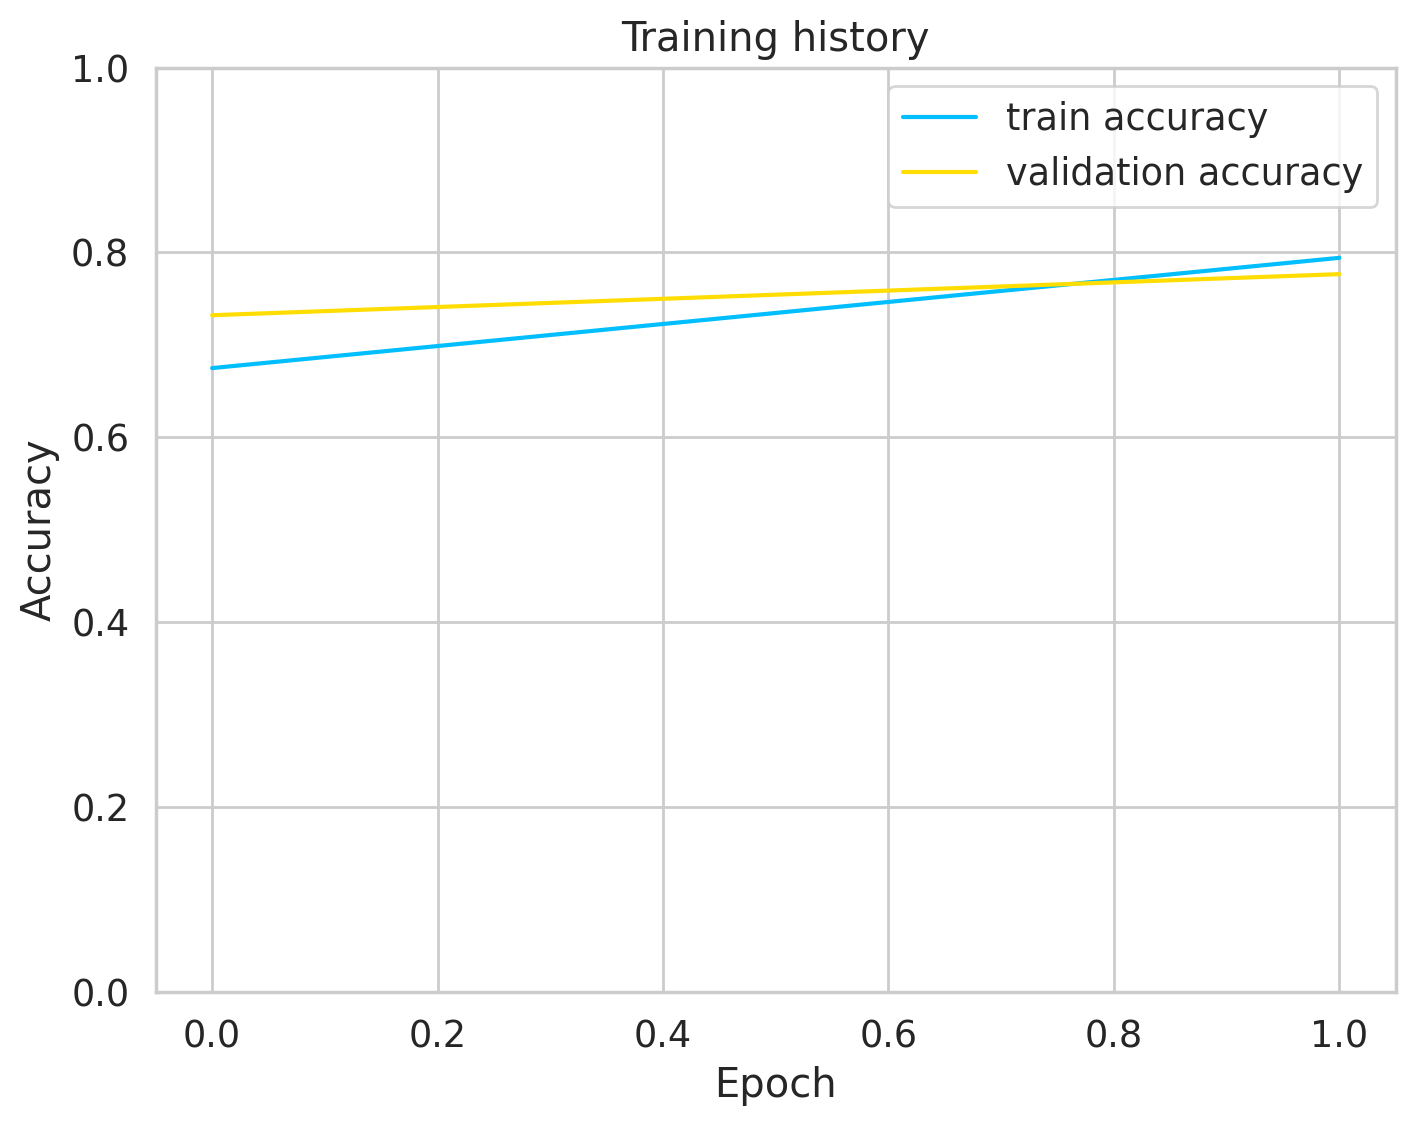

In [74]:
plt.plot(history['train_acc'], label='train accuracy')
plt.plot(history['val_acc'], label='validation accuracy')

plt.title('Training history')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.ylim([0, 1]);

In [ ]:
'''
model = SentimentClassifier(len(class_names))
model.load_state_dict(torch.load('best_model_state.bin'))
model = model.to(device)
'''

"\nmodel = SentimentClassifier(len(class_names))\nmodel.load_state_dict(torch.load('best_model_state.bin'))\nmodel = model.to(device)\n"

## Оценка результатов работы модели

Подсчитаем точность (accuracy) модели на тестовой выборке.

In [75]:
test_acc, _ = eval_model(
  model,
  test_data_loader,
  loss_fn,
  device,
  len(df_test)
)

test_acc.item()

Evaluating: 100%|██████████| 50/50 [00:06<00:00,  7.63it/s]


0.7664974331855774

Accuracy на тестовых данных и на валидационной выборке дают близкие значения. Из этого можно сделать вывод, что получившаяся модель обладает хорошей обобщающей способностью.

In [76]:
print(df.columns)

Index(['userName', 'userImage', 'content', 'score', 'thumbsUpCount',
       'reviewCreatedVersion', 'at', 'replyContent', 'repliedAt', 'sortOrder',
       'appId', 'sentiment'],
      dtype='object')


Теперь реализуем вспомогательную функцию, которая будет получать предсказания из нашей модели.

In [77]:
def get_predictions(model, data_loader):
  model = model.eval()

  review_texts = []
  predictions = []
  prediction_probs = []
  real_values = []

  with torch.no_grad():
    for d in data_loader:

      texts = d["review_text"]
      input_ids = d["input_ids"].to(device)
      attention_mask = d["attention_mask"].to(device)
      targets = d["targets"].to(device)

      outputs = model(
        input_ids=input_ids,
        attention_mask=attention_mask
      )
      preds = torch.argmax(outputs, dim=1)

      probs = F.softmax(outputs, dim=1)

      review_texts.extend(texts)
      predictions.extend(preds)
      prediction_probs.extend(probs)
      real_values.extend(targets)

  predictions = torch.stack(predictions).cpu()
  prediction_probs = torch.stack(prediction_probs).cpu()
  real_values = torch.stack(real_values).cpu()
  return review_texts, predictions, prediction_probs, real_values

In [78]:
y_review_texts, y_pred, y_pred_probs, y_test = get_predictions(model, test_data_loader)

Давайте посмотрим на результаты работы модели на тестовой выборке.

In [79]:
print(classification_report(y_test, y_pred, target_names=class_names))

              precision    recall  f1-score   support

    negative       0.80      0.75      0.77       245
     neutral       0.65      0.67      0.66       254
    positive       0.84      0.87      0.85       289

    accuracy                           0.77       788
   macro avg       0.76      0.76      0.76       788
weighted avg       0.77      0.77      0.77       788




# **Примените к данным готовую модель для классификации последовательности (типа BertForSequenceClassification)**

In [ ]:
df.sample(5)

,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,sortOrder,appId,sentiment
8124,Sam McDonough,https://lh3.googleusercontent.com/-QI1JvHr9vBY...,Great however marking down one star as can't f...,4,1,1.2.3,2020-03-07 22:37:27,Hi Sam: We are working on that and will be add...,2020-03-08 00:39:34,newest,com.habitnow,2
2907,t g,https://lh3.googleusercontent.com/-qRKjG4mqdt0...,"Great app! It will be the best app, if develop...",3,0,NaN,2018-09-30 23:03:00,NaN,NaN,most_relevant,com.ticktick.task,1
7627,kuenzang nima,https://lh3.googleusercontent.com/-k9JfYBg-Yfo...,Nice app. Bug with achievement exp gained. It ...,4,0,2.22.0,2020-03-10 18:22:48,Thanks for the feedback.\nI'll take a look on ...,2020-03-18 14:24:24,newest,com.levor.liferpgtasks,2
8940,Anja Porter,https://lh3.googleusercontent.com/a-/AOh14GiW9...,Had to create Microsoft account to use which a...,3,3,2.6.141,2019-12-16 13:57:25,NaN,NaN,most_relevant,com.microsoft.todos,1
4393,Sarah parsons,https://lh3.googleusercontent.com/-qpb4vD7YTGk...,I can't register because everytime I trie it s...,3,0,NaN,2018-06-18 23:44:48,NaN,NaN,newest,com.habitrpg.android.habitica,1


In [86]:
class GPReviewDataset(Dataset):

  def __init__(self, reviews, labels, tokenizer, max_len):
    self.reviews = reviews
    self.labels = labels # поменяла targets на labels
    self.tokenizer = tokenizer
    self.max_len = max_len

  def __len__(self):
    return len(self.reviews)

  def __getitem__(self, item):
    review = str(self.reviews[item])
    label = self.labels[item]

    encoding = self.tokenizer.encode_plus(
      review,
      add_special_tokens=True,
      max_length=self.max_len,
      return_token_type_ids=False,
      padding='max_length',
      return_attention_mask=True,
      return_tensors='pt',
      truncation=True
    )

    return {
      'review_text': review,
      'input_ids': encoding['input_ids'].flatten(),
      'attention_mask': encoding['attention_mask'].flatten(),
      'labels': torch.tensor(label, dtype=torch.long) # поменяла targets на label, потому что там, где на trainer, он показывал, что ждет labels от меня, target не распознает
    }

In [87]:
def create_data_loader(df, tokenizer, max_len, batch_size):
  ds = GPReviewDataset(
    reviews=df.content.to_numpy(),
    labels=df.sentiment.to_numpy(), # извлекает метки sentiment из столбца sentiment фрейма данных df и преобразует их в массив NumPy, они передаются в качестве меток в ваш GPReviewDataset
    tokenizer=tokenizer,
    max_len=max_len
  )

  return DataLoader(
    ds,
    batch_size=batch_size,
    num_workers=0
  )

In [88]:
BATCH_SIZE = 16

train_data_loader = create_data_loader(df_train, tokenizer, MAX_LEN, BATCH_SIZE)
val_data_loader = create_data_loader(df_val, tokenizer, MAX_LEN, BATCH_SIZE)
test_data_loader = create_data_loader(df_test, tokenizer, MAX_LEN, BATCH_SIZE)

In [89]:
from sklearn.metrics import precision_recall_fscore_support, accuracy_score

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='weighted') #во первых передаю labels, так как многоклассовая классификация, то поставила weighted
    acc = accuracy_score(labels, preds)
    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }
# weighted: чаще всего предпочтителен для многоклассовой классификации, особенно при наличии классового дисбаланса
# macro : подходит, когда нет сильного классового дисбаланса (или вы хотите его игнорировать)
# micro: используется, когда вы хотите вычислить глобальные показатели по всем меткам или когда вы имеете дело с классификацией по нескольким меткам

In [90]:
from transformers import Trainer, TrainingArguments, BertForSequenceClassification
# Trainer - класс обрабатывает основной цикл обучения для моделей-трансформеров, TrainingArg - класс содержит все гиперпараметры и конфигурации для процесса обучения
#тренировочные параметры
training_args = TrainingArguments(
    output_dir='./results',
    evaluation_strategy='epoch',
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=2,
    warmup_steps=500, # количество этапов для планировщика скорости обучения, во время прогрева скорость обучения увеличивается с небольшого начального значения до начальной скорости обучения
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=10,
    run_name="bert-sentiment-analysis" #  название тренировочного цикла для отслеживания и идентификации тренировочных заданий при использовании весов и смещений (wandb)
)

In [83]:
model = BertForSequenceClassification.from_pretrained(PRE_TRAINED_MODEL_NAME, num_labels=3)
# предварительно обученная модель BERT для классификации последовательностей
# обученные веса модели BERT
# классификации с помощью num_labels=3, у нас получатся, что модель обучается классификации по трем различным классам

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at google-bert/bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [91]:
trainer = Trainer(
    model=model,   # наша модель
    args=training_args,  # параметры #TrainingArguments
    train_dataset=train_data_loader.dataset,  # датасет для трейна
    eval_dataset=val_data_loader.dataset,  # валидационный датасет
    compute_metrics=compute_metrics,   # calculates metrics such as accuracy, precision, recall, and F1-score
)
# инициализирует класс Hugging Face Trainer, который управляет циклом обучения и оценки модели

In [92]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.724500,0.578992,0.753494,0.750381,0.750681,0.753494
2,0.425600,0.478770,0.811944,0.812697,0.814616,0.811944


TrainOutput(global_step=1772, training_loss=0.6148474680650853, metrics={'train_runtime': 806.8353, 'train_samples_per_second': 35.127, 'train_steps_per_second': 2.196, 'total_flos': 2330362651639680.0, 'train_loss': 0.6148474680650853, 'epoch': 2.0})

In [93]:
trainer.evaluate()

{'eval_loss': 0.47877031564712524,
 'eval_accuracy': 0.8119440914866582,
 'eval_f1': 0.8126972428742647,
 'eval_precision': 0.8146163862618343,
 'eval_recall': 0.8119440914866582,
 'eval_runtime': 6.8649,
 'eval_samples_per_second': 114.642,
 'eval_steps_per_second': 7.283,
 'epoch': 2.0}

In [94]:
trainer.evaluate(eval_dataset=test_data_loader.dataset, metric_key_prefix="test")
#  задает префикс для ключей метрики в результатах оценки, помогает сохранить показатели четкими и конкретными при использовании нескольких оценочных вызовов

{'test_loss': 0.47280171513557434,
 'test_accuracy': 0.8286802030456852,
 'test_f1': 0.8293469447578249,
 'test_precision': 0.8317198416844034,
 'test_recall': 0.8286802030456852,
 'test_runtime': 7.0799,
 'test_samples_per_second': 111.3,
 'test_steps_per_second': 7.062,
 'epoch': 2.0}


# **Обучите ту модель, которую мы разбирали на занятии (класс SentimentClassifier из тетрадки**

In [95]:
class SentimentClassifier(nn.Module):

  def __init__(self, n_classes):
    super().__init__()
    self.bert = BertModel.from_pretrained(PRE_TRAINED_MODEL_NAME)
    self.drop = nn.Dropout(p=0.3)
    self.classifier = nn.Linear(self.bert.config.hidden_size, n_classes) # bert.config.hidden_size позволяет получить скрытый размер слоев модели BERT

  def forward(self, input_ids, attention_mask, labels=None):
     outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
     pooled_output = outputs[1]
    # голова классификатора
     logits = self.classifier(pooled_output) #к pooled_output применяется уровень линейного классификатора (self.classifier)

     loss = None
     if labels is not None:
        loss_fn = nn.CrossEntropyLoss()
        loss = loss_fn(logits, labels) # вычисляет потерю перекрестной энтропии между логитами модели и истинными метками

     return {'loss': loss, 'logits': logits} # возвращает словарь, содержащий потери и логиты

In [96]:
model = SentimentClassifier(n_classes=3)

In [97]:
trainer = Trainer(
    model=model,   # наша модель
    args=training_args,  # параметры
    train_dataset=train_data_loader.dataset,  # датасет для трейна
    eval_dataset=val_data_loader.dataset,  # валидационный датасет
    compute_metrics=compute_metrics,   # метрики
)

In [98]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.667200,0.580095,0.738247,0.733375,0.731683,0.738247
2,0.387300,0.466725,0.822109,0.821795,0.822031,0.822109


TrainOutput(global_step=1772, training_loss=0.6110924521028054, metrics={'train_runtime': 812.1651, 'train_samples_per_second': 34.897, 'train_steps_per_second': 2.182, 'total_flos': 0.0, 'train_loss': 0.6110924521028054, 'epoch': 2.0})

In [99]:
trainer.evaluate()

{'eval_loss': 0.4667254388332367,
 'eval_accuracy': 0.8221092757306226,
 'eval_f1': 0.8217950613906442,
 'eval_precision': 0.8220313349745078,
 'eval_recall': 0.8221092757306226,
 'eval_runtime': 6.904,
 'eval_samples_per_second': 113.992,
 'eval_steps_per_second': 7.242,
 'epoch': 2.0}

In [100]:
trainer.evaluate(eval_dataset=test_data_loader.dataset, metric_key_prefix="test")

{'test_loss': 0.45840147137641907,
 'test_accuracy': 0.8362944162436549,
 'test_f1': 0.8363414983353153,
 'test_precision': 0.837151233586899,
 'test_recall': 0.8362944162436549,
 'test_runtime': 6.988,
 'test_samples_per_second': 112.764,
 'test_steps_per_second': 7.155,
 'epoch': 2.0}


# **Измените модель, чтобы помимо выхода с пуллер-слоя использовался эмбеддинг cls-токена с последнего слоя**

In [101]:
class CLSClassifier(nn.Module):

  def __init__(self, n_classes):
    super().__init__()
    self.bert = BertModel.from_pretrained(PRE_TRAINED_MODEL_NAME)
    self.drop = nn.Dropout(p=0.3)
    self.classifier = nn.Linear(self.bert.config.hidden_size * 2, n_classes) # входной размер линейного слоя в два раза превышает скрытый размер модели BERT, это связано с тем, что мы собираемся объединить два вектора hidden_size

  def forward(self, input_ids, attention_mask, labels=None):
     outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
     pooled_output = outputs[1]  # output where pool layer

     pooled_output = outputs.pooler_output
     cls_token_emb = outputs.last_hidden_state[:, 0, :] # 1-й токен во входной последовательности = индекс 0 параметра sequence_length dim

     # объединяет pooled_output и cls_token_emb (встраивание токена [CLS]) по измерению 1 (скрытое измерение размера)
     # Два тензора pooled_output и cls_token_emb объединяются вместе, чтобы создать новый тензор с удвоенным скрытым измерением
     combined_output = torch.cat((pooled_output, cls_token_emb), dim=1)

     logits = self.classifier(combined_output)

     loss = None
     if labels is not None:
        loss_fn = nn.CrossEntropyLoss()
        loss = loss_fn(logits, labels)

     return {'loss': loss, 'logits': logits}

In [102]:
model = CLSClassifier(n_classes=3)

In [103]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_data_loader.dataset,
    eval_dataset=val_data_loader.dataset,
    compute_metrics=compute_metrics,
)

In [104]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.668300,0.555740,0.749682,0.746213,0.745076,0.749682
2,0.373500,0.444513,0.832274,0.832694,0.833664,0.832274


TrainOutput(global_step=1772, training_loss=0.5939781294786634, metrics={'train_runtime': 807.7402, 'train_samples_per_second': 35.088, 'train_steps_per_second': 2.194, 'total_flos': 0.0, 'train_loss': 0.5939781294786634, 'epoch': 2.0})

In [105]:
trainer.evaluate()

{'eval_loss': 0.4445129930973053,
 'eval_accuracy': 0.832274459974587,
 'eval_f1': 0.8326939883976519,
 'eval_precision': 0.833664270580333,
 'eval_recall': 0.832274459974587,
 'eval_runtime': 6.9119,
 'eval_samples_per_second': 113.862,
 'eval_steps_per_second': 7.234,
 'epoch': 2.0}

In [106]:
trainer.evaluate(eval_dataset=test_data_loader.dataset, metric_key_prefix="test")

{'test_loss': 0.44392189383506775,
 'test_accuracy': 0.8464467005076142,
 'test_f1': 0.8465212850234418,
 'test_precision': 0.8485646136219382,
 'test_recall': 0.8464467005076142,
 'test_runtime': 6.8441,
 'test_samples_per_second': 115.136,
 'test_steps_per_second': 7.306,
 'epoch': 2.0}

# **Дальше не нужно смотреть, это пример на семинаре**

Решила не чистить, так как было удобно копировать отсюда коды

Из данного отчета видно, что сложнее всего классифицировать нейтральные отзывы.

Посмотрим также на confusion matrix предсказаний модели на тестовой выборке.

In [ ]:
def show_confusion_matrix(confusion_matrix):
  hmap = sns.heatmap(confusion_matrix, annot=True, fmt="d", cmap="Blues")
  hmap.yaxis.set_ticklabels(hmap.yaxis.get_ticklabels(), rotation=0, ha='right')
  hmap.xaxis.set_ticklabels(hmap.xaxis.get_ticklabels(), rotation=30, ha='right')
  plt.ylabel('True sentiment')
  plt.xlabel('Predicted sentiment');

cm = confusion_matrix(y_test, y_pred)
df_cm = pd.DataFrame(cm, index=class_names, columns=class_names)
show_confusion_matrix(df_cm)

Здесь также можно видеть, что модели сложнее всего классифицировать нейтральные отзывы.

In [ ]:
idx = 2

review_text = y_review_texts[idx]
true_sentiment = y_test[idx]
pred_df = pd.DataFrame({
  'class_names': class_names,
  'values': y_pred_probs[idx]
})

In [ ]:
print("\n".join(wrap(review_text)))
print()
print(f'True sentiment: {class_names[true_sentiment]}')

## Предсказание на произвольных текстах

Теперь нам осталось научиться использовать нашу модель для предсказания тональности любого текста.

In [ ]:
review_text = "I love completing my todos! Best app ever!!!"

Для использования нашей модели нам следует токенизировать текст соответствующим образом.

In [ ]:
encoded_review = tokenizer.encode_plus(
  review_text,
  max_length=MAX_LEN,
  add_special_tokens=True,
  return_token_type_ids=False,
  padding='max_length',
  return_attention_mask=True,
  return_tensors='pt',
  truncation=True
)

Теперь получим предсказания нашей модели.

In [ ]:
input_ids = encoded_review['input_ids'].to(device)
attention_mask = encoded_review['attention_mask'].to(device)

output = model(input_ids, attention_mask)
prediction = torch.argmax(output, dim=1)

print(f'Review text: {review_text}')
print(f'Sentiment  : {class_names[prediction]}')

##Trainer от HuggingFace

Библиотека HuggingFace предоставляет инструменты, которые упрощают обучение и оценку моделей, выложенных в репозиторий библиотеки. Рассмотрим эти инструменты на примере задачи анализа тональности. Будем обучать и оценивать модели на датасете imdb, состоящем из отзывов пользователей о фильмах.

Оригинал: https://huggingface.co/transformers/custom_datasets.html#sequence-classification-with-imdb-reviews

Для загрузки датасета воспользуемся библиотекой datasets, реализованной HuggingFace. Данная библиотека предоставляет возможность быстро и удобно скачивать различные бенчмарки: https://huggingface.co/datasets

In [ ]:
!pip install datasets

In [ ]:
from datasets import load_dataset

imdb_dataset = load_dataset('imdb')

In [ ]:
imdb_dataset

In [ ]:
imdb_dataset["train"]["text"][:10]

In [ ]:
imdb_dataset["train"]["label"][:10]

Сократим количество примеров, чтобы процесс обучения был быстрее.

In [ ]:
train_texts = imdb_dataset["train"]["text"][:2000]
train_labels = imdb_dataset["train"]["label"][:2000]
test_texts = imdb_dataset["test"]["text"][:1000]
test_labels = imdb_dataset["test"]["label"][:1000]

In [ ]:
del imdb_dataset

Выделим часть обучающих данных для оценки:

In [ ]:
from sklearn.model_selection import train_test_split
train_texts, val_texts, train_labels, val_labels = train_test_split(train_texts, train_labels, test_size=.2)

Токенизируем данные

In [ ]:
from transformers import DistilBertTokenizerFast
tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

In [ ]:
train_encodings = tokenizer(train_texts, truncation=True, padding=True)
val_encodings = tokenizer(val_texts, truncation=True, padding=True)
test_encodings = tokenizer(test_texts, truncation=True, padding=True)

Создадим класс Dataset, который на каждой итерации будет возвращать токенизированный отзыв и класс:

In [ ]:
class IMDbDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = IMDbDataset(train_encodings, train_labels)
val_dataset = IMDbDataset(val_encodings, val_labels)
test_dataset = IMDbDataset(test_encodings, test_labels)

Опишем функцию для подсчета метрик, которые хотим увидеть при оценке модели (по умолчанию будет вычисляться только loss):

In [ ]:
from sklearn.metrics import precision_recall_fscore_support, accuracy_score

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='binary')
    acc = accuracy_score(labels, preds)
    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

Зададим параметры обучения с помощью TrainingArguments:

In [ ]:
from transformers import DistilBertForSequenceClassification, Trainer, TrainingArguments

training_args = TrainingArguments(
    output_dir='./results',          # output directory
    num_train_epochs=2,              # total number of training epochs
    per_device_train_batch_size=8,  # batch size per device during training
    per_device_eval_batch_size=16,   # batch size for evaluation
    warmup_steps=500,                # number of warmup steps for learning rate scheduler
    weight_decay=0.01,               # strength of weight decay
    logging_dir='./logs',            # directory for storing logs
    logging_steps=10,
)

Инициализируем модель и запустим fine-tune ее с помощью модуля Trainer. В данном модуле будет автоматически происходить итерация по эпохам, батчам, рассчет функции потерь и градиентов, ничего этого больше руками прописывать не нужно!

In [ ]:
model = DistilBertForSequenceClassification.from_pretrained("distilbert-base-uncased")

In [ ]:
trainer = Trainer(
    model=model,                         # the instantiated 🤗 Transformers model to be trained
    args=training_args,                  # training arguments, defined above
    train_dataset=train_dataset,         # training dataset
    eval_dataset=val_dataset,            # evaluation dataset
    compute_metrics = compute_metrics    # metrics to evaluate
)

trainer.train()

In [ ]:
trainer.evaluate()

Оценим модель на тестовых данных

In [ ]:
trainer.evaluate(eval_dataset=test_dataset, metric_key_prefix="test")